In [1]:
import pandas as pd

In [9]:
df = pd.read_csv('train.csv')

In [10]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
df.shape

(42000, 785)

In [12]:
import matplotlib.pyplot as plt

In [22]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
6776,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


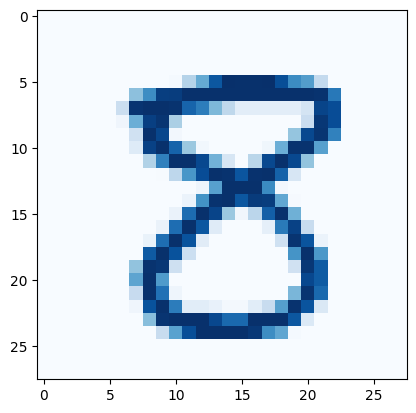

In [16]:
plt.imshow(df.iloc[28358,1:].values.reshape(28,28), cmap='Blues')

In [17]:
X = df.iloc[:,1:].values
Y = df.iloc[:,0].values

In [18]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(42000, 784))

In [19]:
Y

array([1, 0, 1, ..., 7, 6, 9], shape=(42000,))

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)


Checking for any missing value

In [28]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [29]:
X_train.shape

(33600, 784)

In [30]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train,Y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
import time 
start = time.time()
knn.score(X_train, Y_train)
end = time.time()
print(f"Time taken: {end - start} seconds")

Time taken: 40.45698380470276 seconds


In [32]:
print(f"Training Accuracy: {knn.score(X_train, Y_train)}")

Training Accuracy: 0.9771726190476191


In [33]:
y_pred = knn.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, y_pred)

0.9648809523809524

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
knn.fit(X_train_scaled, Y_train)
y_pred_scaled = knn.predict(X_test_scaled)
accuracy_score(Y_test, y_pred_scaled)

0.9391666666666667

Without scaling we are getting better results.
Hence we should go with our old columns .

PCA

In [37]:
from sklearn.decomposition import PCA
pca = PCA(n_components=200)

In [38]:
pca.fit(X_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",200
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

In [39]:
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [40]:
Y_pred_pca = knn.predict(X_test_pca)
accuracy_score(Y_pred_pca, Y_test)

ValueError: X has 200 features, but KNeighborsClassifier is expecting 784 features as input.

In [41]:
from sklearn.neighbors import KNeighborsClassifier
knn_pca = KNeighborsClassifier()
Y_pred_pca = knn_pca.fit(X_train_pca)
accuracy_score(Y_pred_pca, Y_test)

TypeError: KNeighborsClassifier.fit() missing 1 required positional argument: 'y'

In [42]:
from sklearn.neighbors import KNeighborsClassifier
knn_pca = KNeighborsClassifier()
Y_pred_pca = knn_pca.fit(X_train_pca, Y_train)
accuracy_score(Y_pred_pca, Y_test)

InvalidParameterError: The 'y_true' parameter of accuracy_score must be an array-like or a sparse matrix. Got KNeighborsClassifier() instead.

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn_pca = KNeighborsClassifier()
knn_pca.fit(X_train_pca, Y_train)
Y_pred_pca = knn_pca.predict(X_test_pca)
accuracy_score(Y_pred_pca, Y_test)

0.9675

In [ ]:
for i in range(1,784,5):
    pca = PCA(n_components=i)
    X_train_pca = pca.fit_transform(X_train)    
    X_test_pca = pca.transform(X_test)
    knn_pca.fit(X_train_pca, Y_train)
    Y_pred_pca = knn_pca.predict(X_test_pca)
    acc = accuracy_score(Y_pred_pca, Y_test)
    print(f"Number of components: {i}, Accuracy: {acc}")

    

In [48]:
# transforming to 2D coordinates 
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [53]:
import plotly.express as px
y_train_trf = Y_train.astype(str)
fig = px.scatter(x=X_train_pca[:,0],
                 y=X_train_pca[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [54]:
!pip install nbformat
!pip install ipywidgets


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]




[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
import plotly.express as px
y_train_trf = Y_train.astype(str)
fig = px.scatter(x=X_train_pca[:,0],
                 y=X_train_pca[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [56]:
import nbformat
print(nbformat.__version__)

5.10.4


In [57]:
import sys
print(sys.executable)

c:\Users\Anshu\Machine Learning\venv\Scripts\python.exe


In [58]:
import plotly.express as px
import plotly.io as pio

# Open plots in default browser
pio.renderers.default = "browser"

y_train_trf = Y_train.astype(str)

fig = px.scatter(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    color=y_train_trf,
    color_discrete_sequence=px.colors.qualitative.G10,
    title="PCA Visualization of Digit Dataset"
)

fig.update_layout(
    xaxis_title="Principal Component 1",
    yaxis_title="Principal Component 2"
)

fig.show()

In [59]:
pca.explained_variance_
# Eigen values

array([335506.57620544, 244807.10511442])

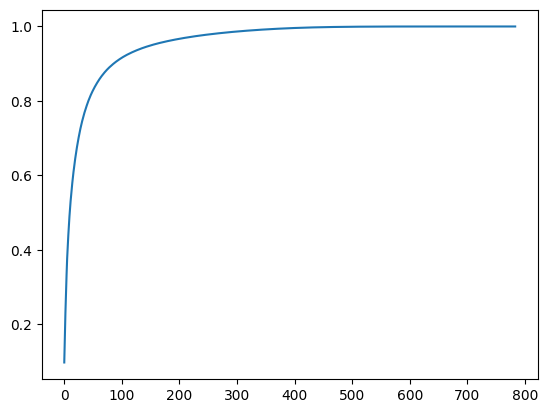

In [64]:
import numpy as np
pca.explained_variance_
# Eigen values
pca.components_.shape
# Eigen vectors
pca.explained_variance_ratio_
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)
pca.explained_variance_.shape
pca.components_.shape
np.cumsum(pca.explained_variance_ratio_)
plt.plot(np.cumsum(pca.explained_variance_ratio_))


Visualing showing the 90% 

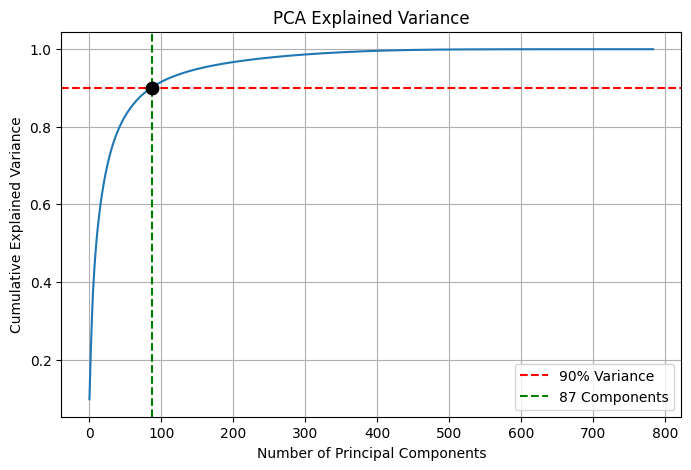

Components needed for 90% variance: 87


In [63]:
import numpy as np
import matplotlib.pyplot as plt

cum_var = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components needed for 90% variance
n_components_90 = np.argmax(cum_var >= 0.90) + 1

plt.figure(figsize=(8,5))
plt.plot(cum_var)

# Horizontal line at 90%
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance')

# Vertical line at corresponding component
plt.axvline(x=n_components_90, color='g', linestyle='--',
            label=f'{n_components_90} Components')

# Mark the intersection point
plt.scatter(n_components_90,
            cum_var[n_components_90-1],
            color='black',
            s=80,
            zorder=5)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

print(f"Components needed for 90% variance: {n_components_90}")